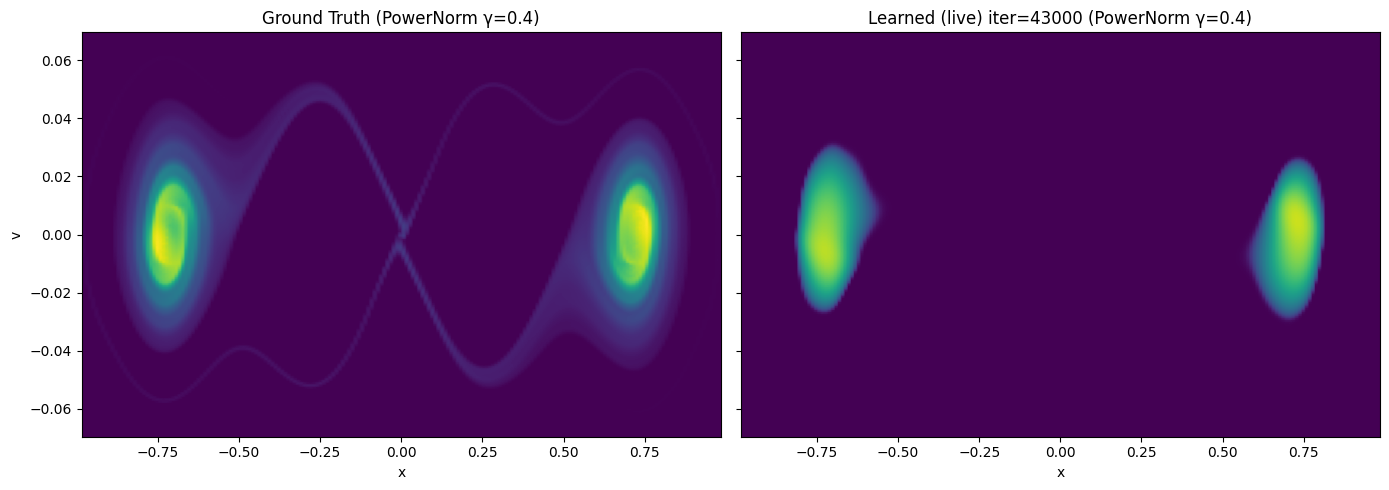


iter= 43500 | loss=-3.796150e-06 | w_theta: Var=2.185e+01  Max=4.157e+01
band       |RS|    Var(RS)       |RG|    Var(RG)
 low  1.658e-04  3.492e-08  4.846e-03  3.192e-05
 mid  4.215e-04  4.234e-07  2.980e-03  1.500e-05
high  1.096e-03  2.694e-06  1.948e-03  6.467e-06


In [ ]:
import math
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from collections import OrderedDict

from IPython.display import display, clear_output
import pandas as pd

# ---------------------------------------------------------------------
# 1. SETUP & ENVIRONMENT
# ---------------------------------------------------------------------
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(123)

min_position, max_position = -0.99, 0.99
max_speed = 0.07
state_low = torch.tensor([min_position, -max_speed], device=device)
state_high = torch.tensor([max_position, max_speed], device=device)

VOL = float((state_high[0] - state_low[0]) * (state_high[1] - state_low[1]))

def tg_alpha(x):
    return 0.1 * (2 * x / (1 - x ** 2) - 2 * math.pi * torch.sin(2 * math.pi * x) - 8 * math.pi * torch.sin(4 * math.pi * x))

def next_state(s, a):
    dt = 0.1
    force_mag = 0.001
    gravity = 0.0025
    x, v = s[:, 0], s[:, 1]
    f = (a.float() * 2 - 1) * force_mag + tg_alpha(x) * (-gravity)
    v = torch.clamp(v + f * dt, -max_speed, max_speed)
    x = torch.clamp(x + v * dt, min_position, max_position)
    return torch.stack([x, v], dim=1)

def sample_proposal(n):
    return state_low + torch.rand(n, 2, device=device) * (state_high - state_low)

def sample_start(n):
    sign = torch.where(torch.rand(n, device=device) < 0.5, -1.0, 1.0)
    pos = sign * (torch.rand(n, device=device) * 0.1 + 0.67)
    vel = (torch.rand(n, device=device) * 2 - 1) * 0.01
    return torch.stack([pos, vel], dim=1)

# ---------------------------------------------------------------------
# 2. LOAD TRAINED POLICY
# ---------------------------------------------------------------------
class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self._fc_policy = nn.Sequential(
            nn.Linear(2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self._fc_policy(x)

policy_net = PolicyNetwork().to(device)

def load_policy_from_triple_net_ckpt(policy_net: PolicyNetwork, ckpt_path: str):
    if not os.path.exists(ckpt_path):
        print(f"WARNING: '{ckpt_path}' not found. Using RANDOM policy.")
        return False

    try:
        sd = torch.load(ckpt_path, map_location=device)
        if not isinstance(sd, dict):
            raise ValueError("Checkpoint is not a state_dict dict.")

        new_sd = OrderedDict()
        for k, v in sd.items():
            k2 = k.replace("module.", "")
            if k2.startswith("_fc_policy."):
                k3 = k2.replace("_fc_policy.", "")
                new_sd[k3] = v

        if len(new_sd) == 0:
            raise KeyError("No _fc_policy.* keys found in checkpoint state_dict.")

        policy_net._fc_policy.load_state_dict(new_sd, strict=True)
        policy_net.eval()
        print(f"SUCCESS: Loaded _fc_policy from {ckpt_path}")
        return True
    except Exception as e:
        print(f"ERROR loading policy from '{ckpt_path}': {e}. Using RANDOM policy.")
        return False

model_path = "mvmc.pth"
load_policy_from_triple_net_ckpt(policy_net, model_path)

@torch.no_grad()
def sample_actions(s):
    return Categorical(logits=policy_net(s)).sample()

# ---------------------------------------------------------------------
# 3. GROUND TRUTH (discounted occupancy histogram)
# ---------------------------------------------------------------------
@torch.no_grad()
def estimate_state_histogram_discounted(gamma=0.99, N=300_000, T=1000, x_bins=200, v_bins=200):
    print("Generating Ground Truth (High Res)...")
    x_edges = torch.linspace(state_low[0], state_high[0], x_bins + 1, device=device)
    v_edges = torch.linspace(state_low[1], state_high[1], v_bins + 1, device=device)
    H = torch.zeros((x_bins, v_bins), device=device, dtype=torch.float64)

    s = sample_start(N)
    w = (1.0 - gamma)
    eps = 1e-12

    for _t in range(T):
        xv = torch.clamp(s[:, 0], x_edges[0], x_edges[-1] - eps)
        vv = torch.clamp(s[:, 1], v_edges[0], v_edges[-1] - eps)

        ix = torch.bucketize(xv, x_edges) - 1
        iv = torch.bucketize(vv, v_edges) - 1

        mask = (ix >= 0) & (ix < x_bins) & (iv >= 0) & (iv < v_bins)
        if mask.any():
            H.index_put_(
                (ix[mask], iv[mask]),
                torch.full((mask.sum(),), w, device=device, dtype=H.dtype),
                accumulate=True
            )

        s = next_state(s, sample_actions(s))
        w *= gamma
        if w < 1e-12:
            break

    H = H / H.sum()
    return H, x_edges, v_edges

# ---------------------------------------------------------------------
# 4. WEAK FORM TRAINING (Multi-Scale Gaussian RFF + constant feature)
# ---------------------------------------------------------------------
class InputScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer("scale", torch.tensor([1.0, 1.0 / 0.07], device=device))

    def forward(self, s):
        return s * self.scale

class DensityNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.scaler = InputScaler()
        self.net = nn.Sequential(
            nn.Linear(2, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 1),
            nn.Softplus()
        )

    def forward(self, s):
        return self.net(self.scaler(s))

class RFFSampler:
    def __init__(self, sigma=1.0):
        self.sigma = sigma
        self.scaler = InputScaler()

    def sample_functions(self, num_functions: int):
        w = torch.randn(num_functions, 2, device=device) * self.sigma
        b = torch.rand(num_functions, 1, device=device) * 2 * np.pi
        return w, b

    def evaluate(self, s, w, b):
        # returns [2*num_functions, batch]
        s_norm = self.scaler(s)
        proj = torch.matmul(w, s_norm.T) + b
        return torch.cat([torch.cos(proj), torch.sin(proj)], dim=0)

def train_weak_form(
    iterations=20_000,
    batch_size=40_000,
    gamma=0.99,
    num_rff=1024,
    lr=1e-4,
    log_every=500,
    # live viz:
    live_viz=True,
    viz_every=500,
    viz_power_gamma=0.4,
    gt_for_viz=None,                # expected shape (v_bins, x_bins)
    xc_for_viz=None, vc_for_viz=None,
    grid_for_viz=None,              # [v_bins*x_bins, 2] with (x,v)
    grid_shape=None,                # (v_bins, x_bins)
):
    model = DensityNetwork().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    samplers = [
        ("low",  RFFSampler(sigma=1.0)),
        ("mid",  RFFSampler(sigma=10.0)),
        ("high", RFFSampler(sigma=30.0)),
    ]

    hist = {
        "iter": [],
        "loss": [],
        "w_var": [],
        "w_max": [],
        "low_RS_abs": [], "low_RS_var": [],
        "mid_RS_abs": [], "mid_RS_var": [],
        "high_RS_abs": [], "high_RS_var": [],
        "low_RG_abs": [], "low_RG_var": [],
        "mid_RG_abs": [], "mid_RG_var": [],
        "high_RG_abs": [], "high_RG_var": [],
    }

    do_viz = (
        live_viz
        and (gt_for_viz is not None)
        and (xc_for_viz is not None)
        and (vc_for_viz is not None)
        and (grid_for_viz is not None)
        and (grid_shape is not None)
    )

    # --- live viz setup (Jupyter-friendly) ---
    if do_viz:
        fig_live, ax_live = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
        norm = PowerNorm(gamma=viz_power_gamma)

        extent = [
            float(xc_for_viz[0].item()), float(xc_for_viz[-1].item()),
            float(vc_for_viz[0].item()), float(vc_for_viz[-1].item())
        ]

        im0 = ax_live[0].imshow(
            gt_for_viz.detach().cpu().numpy(),  # (v_bins, x_bins)
            origin="lower",
            aspect="auto",
            extent=extent,
            norm=norm,
            cmap="viridis",
        )
        ax_live[0].set_title(f"Ground Truth (PowerNorm γ={viz_power_gamma})")
        ax_live[0].set_xlabel("x")
        ax_live[0].set_ylabel("v")

        im1 = ax_live[1].imshow(
            np.zeros(grid_shape, dtype=np.float32),
            origin="lower",
            aspect="auto",
            extent=extent,
            norm=norm,
            cmap="viridis",
        )
        ax_live[1].set_title(f"Learned (live) (PowerNorm γ={viz_power_gamma})")
        ax_live[1].set_xlabel("x")

        plt.tight_layout()
        display(fig_live)

    print(f"Starting Training ({iterations} steps)...")

    for i in range(iterations):
        s  = sample_proposal(batch_size)
        ns = next_state(s, sample_actions(s))
        s0 = sample_start(batch_size)

        st  = sample_proposal(batch_size)
        nst = next_state(st, sample_actions(st))

        optimizer.zero_grad()
        total_loss = 0.0

        d  = model(s).squeeze(-1)
        dt = model(st).squeeze(-1)

        wS = d  * VOL
        wT = dt * VOL

        stats = {}

        for name, rff in samplers:
            wf, bf = rff.sample_functions(num_functions=num_rff)

            f_s   = rff.evaluate(s,   wf, bf)
            f_ns  = rff.evaluate(ns,  wf, bf)
            f_s0  = rff.evaluate(s0,  wf, bf)
            f_st  = rff.evaluate(st,  wf, bf)
            f_nst = rff.evaluate(nst, wf, bf)

            ones = torch.ones(1, batch_size, device=device)
            f_s   = torch.cat([f_s,   ones], dim=0)
            f_ns  = torch.cat([f_ns,  ones], dim=0)
            f_s0  = torch.cat([f_s0,  ones], dim=0)
            f_st  = torch.cat([f_st,  ones], dim=0)
            f_nst = torch.cat([f_nst, ones], dim=0)

            with torch.no_grad():
                R_S = (wS * (f_s - gamma * f_ns)).mean(dim=1) - (1.0 - gamma) * f_s0.mean(dim=1)

            R_St_grad = (wT * (f_st - gamma * f_nst)).mean(dim=1)

            total_loss = total_loss + 2.0 * (R_S * R_St_grad).mean()

            if (i % log_every) == 0:
                stats[name] = {
                    "RS_abs": float(R_S.abs().mean().item()),
                    "RS_var": float(R_S.var(unbiased=False).item()),
                    "RG_abs": float(R_St_grad.abs().mean().item()),
                    "RG_var": float(R_St_grad.var(unbiased=False).item()),
                }

        total_loss.backward()
        optimizer.step()

        if (i % log_every) == 0:
            w_var = float(wS.var(unbiased=False).item())
            w_max = float(wS.max().item())

            hist["iter"].append(i)
            hist["loss"].append(float(total_loss.item()))
            hist["w_var"].append(w_var)
            hist["w_max"].append(w_max)

            for band in ["low", "mid", "high"]:
                dct = stats.get(band, None)
                if dct is None:
                    continue
                hist[f"{band}_RS_abs"].append(dct["RS_abs"])
                hist[f"{band}_RS_var"].append(dct["RS_var"])
                hist[f"{band}_RG_abs"].append(dct["RG_abs"])
                hist[f"{band}_RG_var"].append(dct["RG_var"])

            # structured logging
            rows = []
            for band in ["low", "mid", "high"]:
                dct = stats.get(band, {})
                rows.append({
                    "band": band,
                    "|RS|": dct.get("RS_abs", np.nan),
                    "Var(RS)": dct.get("RS_var", np.nan),
                    "|RG|": dct.get("RG_abs", np.nan),
                    "Var(RG)": dct.get("RG_var", np.nan),
                })
            df = pd.DataFrame(rows)

            print("\n" + "=" * 105)
            print(f"iter={i:6d} | loss={total_loss.item(): .6e} | w_theta: Var={w_var:.3e}  Max={w_max:.3e}")
            print(df.to_string(index=False, float_format=lambda x: f"{x: .3e}"))

        # live viz update
        if do_viz and (i % viz_every) == 0:
            with torch.no_grad():
                pred_grid = model(grid_for_viz).reshape(grid_shape)     # (v_bins, x_bins)
                pred_grid = pred_grid / (pred_grid.sum() + 1e-12)

            im1.set_data(pred_grid.detach().cpu().numpy())
            ax_live[1].set_title(f"Learned (live) iter={i} (PowerNorm γ={viz_power_gamma})")

            clear_output(wait=True)
            display(fig_live)

    return model, hist

# ---------------------------------------------------------------------
# 5. RUN + VISUALIZATION (final)
# ---------------------------------------------------------------------
gt_H, x_e, v_e = estimate_state_histogram_discounted(N=300_000, T=1000, gamma=0.99, x_bins=200, v_bins=200)

xc = 0.5 * (x_e[:-1] + x_e[1:])
vc = 0.5 * (v_e[:-1] + v_e[1:])

# IMPORTANT:
# - gt_H is (x_bins, v_bins) due to how we index_put with (ix, iv)
# - For plotting as (y,x) = (v_bins, x_bins), we transpose ONCE here
# - Predictions will NOT be transposed.
gt_disp = (gt_H / gt_H.sum()).T.contiguous()  # (v_bins, x_bins)

# Build grid with shape (v_bins, x_bins) so reshape matches gt_disp
Vg, Xg = torch.meshgrid(vc, xc, indexing="ij")  # (v_bins, x_bins)
grid = torch.stack([Xg.flatten(), Vg.flatten()], dim=1)  # [v_bins*x_bins, 2] with (x, v)

model, hist = train_weak_form(
    iterations=50000,
    batch_size=50000,
    gamma=0.99,
    num_rff=1024,
    lr=1e-4,
    log_every=500,
    live_viz=True,
    viz_every=500,
    viz_power_gamma=0.4,
    gt_for_viz=gt_disp,
    xc_for_viz=xc,
    vc_for_viz=vc,
    grid_for_viz=grid,
    grid_shape=gt_disp.shape,   # (v_bins, x_bins)
)

with torch.no_grad():
    preds = model(grid).reshape(gt_disp.shape)  # (v_bins, x_bins)  <-- NO TRANSPOSE
    preds = preds / (preds.sum() + 1e-12)

# Final side-by-side density plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
extent = [float(xc[0]), float(xc[-1]), float(vc[0]), float(vc[-1])]

ax[0].imshow(gt_disp.cpu().numpy(), origin="lower", aspect="auto",
             extent=extent, cmap="viridis", norm=PowerNorm(gamma=0.4))
ax[0].set_title("Ground Truth (Monte Carlo) (PowerNorm γ=0.4)")
ax[0].set_xlabel("x")
ax[0].set_ylabel("v")

ax[1].imshow(preds.cpu().numpy(), origin="lower", aspect="auto",
             extent=extent, cmap="viridis", norm=PowerNorm(gamma=0.4))
ax[1].set_title("Learned (PowerNorm γ=0.4)")
ax[1].set_xlabel("x")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 6. Structured diagnostics figure (one clean 3x2 subplot layout)
# ---------------------------------------------------------------------
iters = np.array(hist["iter"])
w_var = np.array(hist["w_var"])
w_max = np.array(hist["w_max"])

fig, ax = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
ax = ax.flatten()

# Residual |RS|
for band in ["low", "mid", "high"]:
    ax[0].plot(iters, np.array(hist[f"{band}_RS_abs"]), label=band)
ax[0].set_title("Residual |RS|")
ax[0].legend()

# Gradient |RG|
for band in ["low", "mid", "high"]:
    ax[1].plot(iters, np.array(hist[f"{band}_RG_abs"]), label=band)
ax[1].set_title("Gradient |RG|")
ax[1].legend()

# Residual variance Var(RS)
for band in ["low", "mid", "high"]:
    ax[2].plot(iters, np.array(hist[f"{band}_RS_var"]), label=band)
ax[2].set_title("Residual variance Var(RS)")
ax[2].legend()

# Gradient variance Var(RG)
for band in ["low", "mid", "high"]:
    ax[3].plot(iters, np.array(hist[f"{band}_RG_var"]), label=band)
ax[3].set_title("Gradient variance Var(RG)")
ax[3].legend()

# w_theta_max
ax[4].plot(iters, w_max)
ax[4].set_title("w_theta_max")

# w_theta_var
ax[5].plot(iters, w_var)
ax[5].set_title("w_theta_var")

for k in range(6):
    ax[k].set_xlabel("Iteration")

plt.tight_layout()
plt.show()


# Experiment 2

Use GELU with Residual Blocks

Donot use constant feature (was not in the derivation) and just uses sampled RFF features

More Sigma Values to capture high frequencies

Also done Experiemnt with large batch size

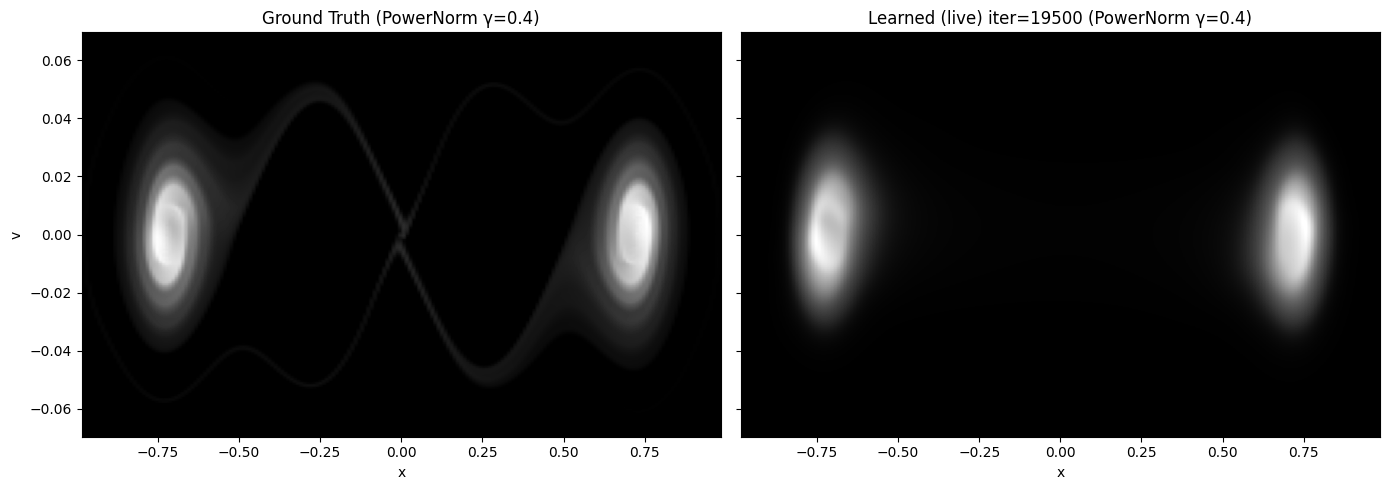

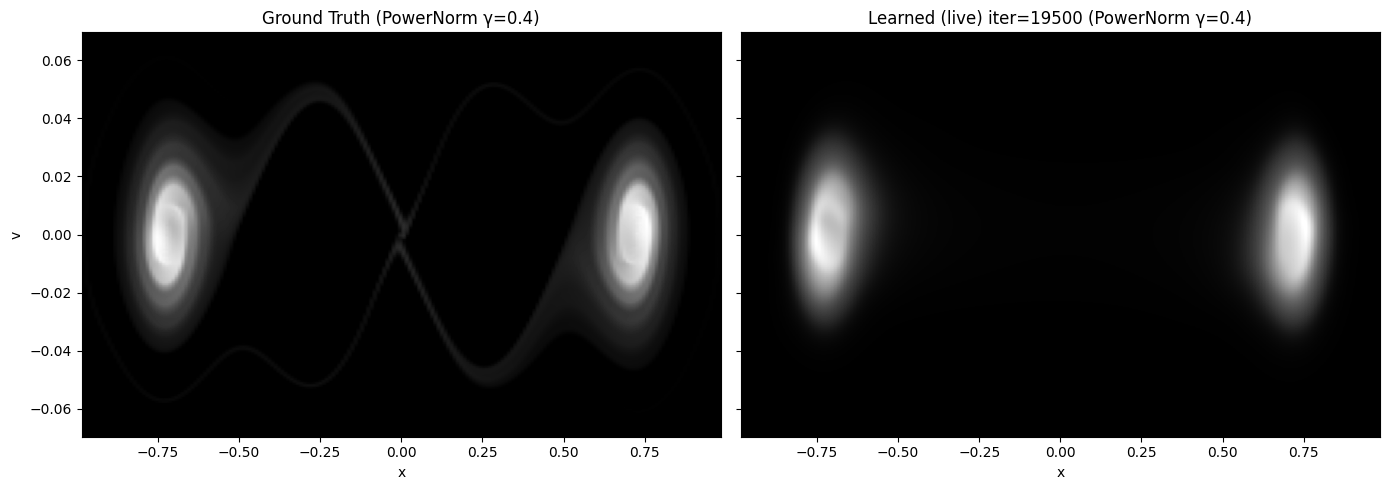

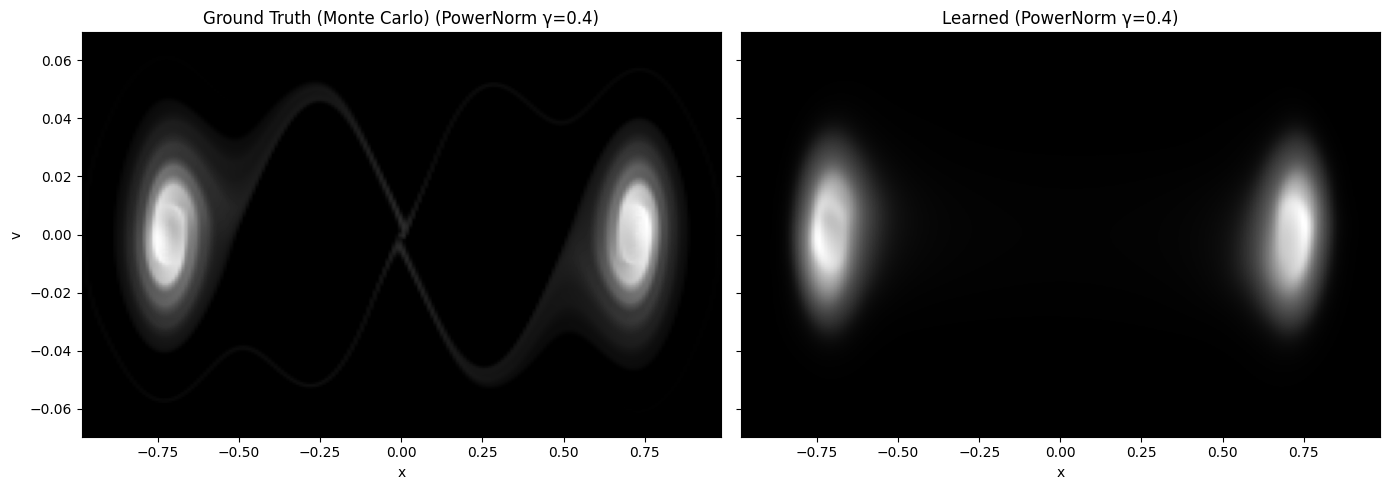

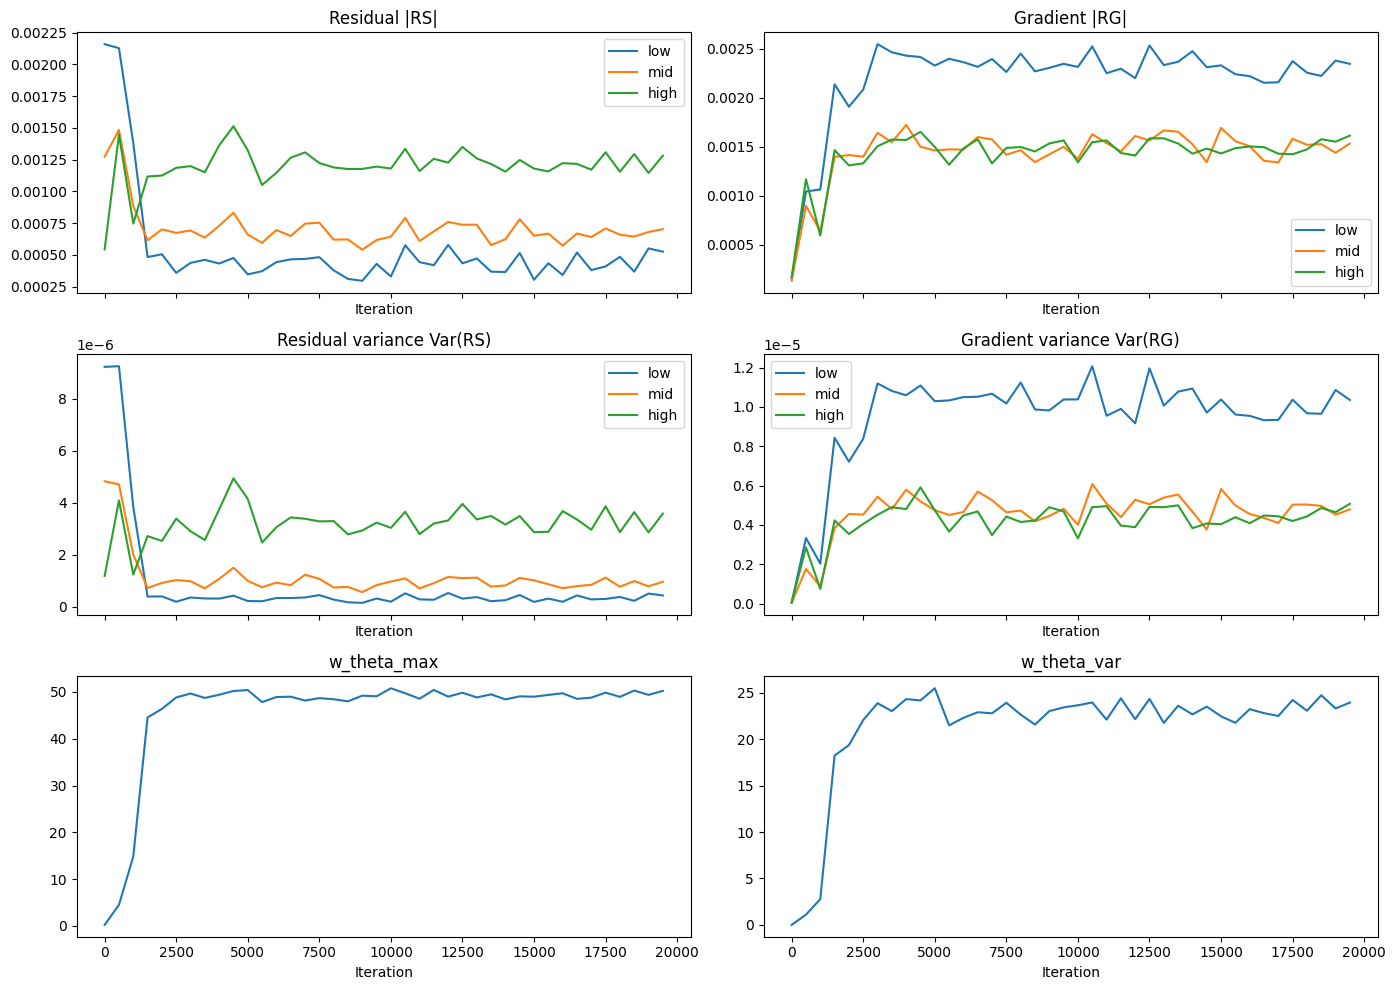

In [ ]:
import math
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from collections import OrderedDict

from IPython.display import display, clear_output
import pandas as pd

# ---------------------------------------------------------------------
# 1. SETUP & ENVIRONMENT
# ---------------------------------------------------------------------
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(123)

min_position, max_position = -0.99, 0.99
max_speed = 0.07
state_low = torch.tensor([min_position, -max_speed], device=device)
state_high = torch.tensor([max_position, max_speed], device=device)

VOL = float((state_high[0] - state_low[0]) * (state_high[1] - state_low[1]))

def tg_alpha(x):
    return 0.1 * (2 * x / (1 - x ** 2) - 2 * math.pi * torch.sin(2 * math.pi * x) - 8 * math.pi * torch.sin(4 * math.pi * x))

def next_state(s, a):
    dt = 0.1
    force_mag = 0.001
    gravity = 0.0025
    x, v = s[:, 0], s[:, 1]
    f = (a.float() * 2 - 1) * force_mag + tg_alpha(x) * (-gravity)
    v = torch.clamp(v + f * dt, -max_speed, max_speed)
    x = torch.clamp(x + v * dt, min_position, max_position)
    return torch.stack([x, v], dim=1)

def sample_proposal(n):
    return state_low + torch.rand(n, 2, device=device) * (state_high - state_low)

def sample_start(n):
    sign = torch.where(torch.rand(n, device=device) < 0.5, -1.0, 1.0)
    pos = sign * (torch.rand(n, device=device) * 0.1 + 0.67)
    vel = (torch.rand(n, device=device) * 2 - 1) * 0.01
    return torch.stack([pos, vel], dim=1)

# ---------------------------------------------------------------------
# 2. LOAD TRAINED POLICY
# ---------------------------------------------------------------------
class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self._fc_policy = nn.Sequential(
            nn.Linear(2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self._fc_policy(x)

policy_net = PolicyNetwork().to(device)

def load_policy_from_triple_net_ckpt(policy_net: PolicyNetwork, ckpt_path: str):
    if not os.path.exists(ckpt_path):
        print(f"WARNING: '{ckpt_path}' not found. Using RANDOM policy.")
        return False

    try:
        sd = torch.load(ckpt_path, map_location=device)
        if not isinstance(sd, dict):
            raise ValueError("Checkpoint is not a state_dict dict.")

        new_sd = OrderedDict()
        for k, v in sd.items():
            k2 = k.replace("module.", "")
            if k2.startswith("_fc_policy."):
                k3 = k2.replace("_fc_policy.", "")
                new_sd[k3] = v

        if len(new_sd) == 0:
            raise KeyError("No _fc_policy.* keys found in checkpoint state_dict.")

        policy_net._fc_policy.load_state_dict(new_sd, strict=True)
        policy_net.eval()
        print(f"SUCCESS: Loaded _fc_policy from {ckpt_path}")
        return True
    except Exception as e:
        print(f"ERROR loading policy from '{ckpt_path}': {e}. Using RANDOM policy.")
        return False

model_path = "mvmc.pth"
load_policy_from_triple_net_ckpt(policy_net, model_path)

@torch.no_grad()
def sample_actions(s):
    return Categorical(logits=policy_net(s)).sample()

# ---------------------------------------------------------------------
# 3. GROUND TRUTH (discounted occupancy histogram)
# ---------------------------------------------------------------------
@torch.no_grad()
def estimate_state_histogram_discounted(gamma=0.95, N=300_000, T=1000, x_bins=200, v_bins=200):
    print("Generating Ground Truth (High Res)...")
    x_edges = torch.linspace(state_low[0], state_high[0], x_bins + 1, device=device)
    v_edges = torch.linspace(state_low[1], state_high[1], v_bins + 1, device=device)
    H = torch.zeros((x_bins, v_bins), device=device, dtype=torch.float64)

    s = sample_start(N)
    w = (1.0 - gamma)
    eps = 1e-12

    for _t in range(T):
        xv = torch.clamp(s[:, 0], x_edges[0], x_edges[-1] - eps)
        vv = torch.clamp(s[:, 1], v_edges[0], v_edges[-1] - eps)

        ix = torch.bucketize(xv, x_edges) - 1
        iv = torch.bucketize(vv, v_edges) - 1

        mask = (ix >= 0) & (ix < x_bins) & (iv >= 0) & (iv < v_bins)
        if mask.any():
            H.index_put_(
                (ix[mask], iv[mask]),
                torch.full((mask.sum(),), w, device=device, dtype=H.dtype),
                accumulate=True
            )

        s = next_state(s, sample_actions(s))
        w *= gamma
        if w < 1e-12:
            break

    H = H / H.sum()
    return H, x_edges, v_edges

# ---------------------------------------------------------------------
# 4. WEAK FORM TRAINING (GELU + residual blocks, multi-scale RFF, + flux test)
# ---------------------------------------------------------------------
class InputScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer("scale", torch.tensor([1.0, 1.0 / 0.07], device=device))

    def forward(self, s):
        return s * self.scale

class ResidualBlock(nn.Module):
    def __init__(self, width: int):
        super().__init__()
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, width)
        self.act = nn.GELU()

    def forward(self, x):
        h = self.act(self.fc1(x))
        h = self.fc2(h)
        return self.act(x + h)

class DensityNetwork(nn.Module):
    def __init__(self, width=256, depth=4):
        super().__init__()
        self.scaler = InputScaler()
        self.inp = nn.Linear(2, width)
        self.blocks = nn.Sequential(*[ResidualBlock(width) for _ in range(depth)])
        self.out = nn.Linear(width, 1)
        self.softplus = nn.Softplus()
        self.act = nn.GELU()

    def forward(self, s):
        x = self.scaler(s)
        x = self.act(self.inp(x))
        x = self.blocks(x)
        x = self.out(x)
        return self.softplus(x)


class RFFSampler:
    def __init__(self, sigma=1.0):
        self.sigma = sigma
        self.scaler = InputScaler()

    def sample_functions(self, num_functions: int):
        w = torch.randn(num_functions, 2, device=device) * self.sigma
        b = torch.rand(num_functions, 1, device=device) * 2 * np.pi
        return w, b

    def evaluate(self, s, w, b):
        s_norm = self.scaler(s)
        proj = torch.matmul(w, s_norm.T) + b
        return torch.cat([torch.cos(proj), torch.sin(proj)], dim=0)

def train_weak_form(
    iterations=20_000,
    batch_size=40_000,
    gamma=0.95,
    num_rff=1024,
    lr=1e-4,
    log_every=500,
    live_viz=True,
    viz_every=500,
    viz_power_gamma=0.4,
    gt_for_viz=None,
    xc_for_viz=None, vc_for_viz=None,
    grid_for_viz=None,
    grid_shape=None,
):
    model = DensityNetwork().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    samplers = [
        ("low",  RFFSampler(sigma=15.0)),
        ("mid",  RFFSampler(sigma=30.0)),
        ("high", RFFSampler(sigma=60.0)),
    ]

    hist = {
        "iter": [],
        "loss": [],
        "w_var": [],
        "w_max": [],
        "low_RS_abs": [], "low_RS_var": [],
        "mid_RS_abs": [], "mid_RS_var": [],
        "high_RS_abs": [], "high_RS_var": [],
        "low_RG_abs": [], "low_RG_var": [],
        "mid_RG_abs": [], "mid_RG_var": [],
        "high_RG_abs": [], "high_RG_var": [],
    }

    do_viz = (
        live_viz
        and (gt_for_viz is not None)
        and (xc_for_viz is not None)
        and (vc_for_viz is not None)
        and (grid_for_viz is not None)
        and (grid_shape is not None)
    )

    if do_viz:
        fig_live, ax_live = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
        norm = PowerNorm(gamma=viz_power_gamma)

        extent = [
            float(xc_for_viz[0].item()), float(xc_for_viz[-1].item()),
            float(vc_for_viz[0].item()), float(vc_for_viz[-1].item())
        ]

        im0 = ax_live[0].imshow(
            gt_for_viz.detach().cpu().numpy(),
            origin="lower",
            aspect="auto",
            extent=extent,
            norm=norm,
            cmap="gray",
        )
        ax_live[0].set_title(f"Ground Truth (PowerNorm γ={viz_power_gamma})")
        ax_live[0].set_xlabel("x")
        ax_live[0].set_ylabel("v")

        im1 = ax_live[1].imshow(
            np.zeros(grid_shape, dtype=np.float32),
            origin="lower",
            aspect="auto",
            extent=extent,
            norm=norm,
            cmap="gray",
        )
        ax_live[1].set_title(f"Learned (live) (PowerNorm γ={viz_power_gamma})")
        ax_live[1].set_xlabel("x")

        plt.tight_layout()
        display(fig_live)

    print(f"Starting Training ({iterations} steps)...")

    eps_norm = 1e-8

    for i in range(iterations):
        s  = sample_proposal(batch_size)
        ns = next_state(s, sample_actions(s))
        s0 = sample_start(batch_size)

        st  = sample_proposal(batch_size)
        nst = next_state(st, sample_actions(st))

        optimizer.zero_grad()
        total_loss = 0.0

        d  = model(s).squeeze(-1)
        dt = model(st).squeeze(-1)

        wS = d  * VOL
        wT = dt * VOL

        stats = {}

        for name, rff in samplers:
            wf, bf = rff.sample_functions(num_functions=num_rff)

            f_s   = rff.evaluate(s,   wf, bf)
            f_ns  = rff.evaluate(ns,  wf, bf)
            f_s0  = rff.evaluate(s0,  wf, bf)
            f_st  = rff.evaluate(st,  wf, bf)
            f_nst = rff.evaluate(nst, wf, bf)

            with torch.no_grad():
                R_S = (wS * (f_s - gamma * f_ns)).mean(dim=1) - (1.0 - gamma) * f_s0.mean(dim=1)

            R_St_grad = (wT * (f_st - gamma * f_nst)).mean(dim=1)

            R_Sn = R_S 
            RGn  = R_St_grad

            total_loss = total_loss + 2.0 * (R_Sn * RGn).mean()

            if (i % log_every) == 0:
                stats[name] = {
                    "RS_abs": float(R_S.abs().mean().item()),
                    "RS_var": float(R_S.var(unbiased=False).item()),
                    "RG_abs": float(R_St_grad.abs().mean().item()),
                    "RG_var": float(R_St_grad.var(unbiased=False).item()),
                }

        total_loss.backward()
        optimizer.step()

        if (i % log_every) == 0:
            w_var = float(wS.var(unbiased=False).item())
            w_max = float(wS.max().item())

            hist["iter"].append(i)
            hist["loss"].append(float(total_loss.item()))
            hist["w_var"].append(w_var)
            hist["w_max"].append(w_max)

            for band in ["low", "mid", "high"]:
                dct = stats.get(band, None)
                if dct is None:
                    continue
                hist[f"{band}_RS_abs"].append(dct["RS_abs"])
                hist[f"{band}_RS_var"].append(dct["RS_var"])
                hist[f"{band}_RG_abs"].append(dct["RG_abs"])
                hist[f"{band}_RG_var"].append(dct["RG_var"])

            rows = []
            for band in ["low", "mid", "high"]:
                dct = stats.get(band, {})
                rows.append({
                    "band": band,
                    "|RS|": dct.get("RS_abs", np.nan),
                    "Var(RS)": dct.get("RS_var", np.nan),
                    "|RG|": dct.get("RG_abs", np.nan),
                    "Var(RG)": dct.get("RG_var", np.nan),
                })
            df = pd.DataFrame(rows)

            print("\n" + "=" * 105)
            print(f"iter={i:6d} | loss={total_loss.item(): .6e} | w_theta: Var={w_var:.3e}  Max={w_max:.3e}")
            print(df.to_string(index=False, float_format=lambda x: f"{x: .3e}"))

        if do_viz and (i % viz_every) == 0:
            with torch.no_grad():
                pred_grid = model(grid_for_viz).reshape(grid_shape)
                pred_grid = pred_grid / (pred_grid.sum() + 1e-12)

            im1.set_data(pred_grid.detach().cpu().numpy())
            ax_live[1].set_title(f"Learned (live) iter={i} (PowerNorm γ={viz_power_gamma})")

            clear_output(wait=True)
            display(fig_live)

    return model, hist

# ---------------------------------------------------------------------
# 5. RUN + VISUALIZATION (final)
# ---------------------------------------------------------------------
gamma_train = 0.99

gt_H, x_e, v_e = estimate_state_histogram_discounted(N=300_000, T=1000, gamma=gamma_train, x_bins=200, v_bins=200)

xc = 0.5 * (x_e[:-1] + x_e[1:])
vc = 0.5 * (v_e[:-1] + v_e[1:])

gt_disp = (gt_H / gt_H.sum()).T.contiguous()  # (v_bins, x_bins)

Vg, Xg = torch.meshgrid(vc, xc, indexing="ij")
grid = torch.stack([Xg.flatten(), Vg.flatten()], dim=1)

model, hist = train_weak_form(
    iterations=20000,
    batch_size=150000,
    gamma=gamma_train,
    num_rff=512,
    lr=1e-4,
    log_every=500,
    live_viz=True,
    viz_every=500,
    viz_power_gamma=0.4,
    gt_for_viz=gt_disp,
    xc_for_viz=xc,
    vc_for_viz=vc,
    grid_for_viz=grid,
    grid_shape=gt_disp.shape,
)

with torch.no_grad():
    preds = model(grid).reshape(gt_disp.shape)
    preds = preds / (preds.sum() + 1e-12)

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
extent = [float(xc[0]), float(xc[-1]), float(vc[0]), float(vc[-1])]

ax[0].imshow(gt_disp.cpu().numpy(), origin="lower", aspect="auto",
             extent=extent, cmap="gray", norm=PowerNorm(gamma=0.4))
ax[0].set_title("Ground Truth (Monte Carlo) (PowerNorm γ=0.4)")
ax[0].set_xlabel("x")
ax[0].set_ylabel("v")

ax[1].imshow(preds.cpu().numpy(), origin="lower", aspect="auto",
             extent=extent, cmap="gray", norm=PowerNorm(gamma=0.4))
ax[1].set_title("Learned (PowerNorm γ=0.4)")
ax[1].set_xlabel("x")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 6. Structured diagnostics figure
# ---------------------------------------------------------------------
iters = np.array(hist["iter"])
w_var = np.array(hist["w_var"])
w_max = np.array(hist["w_max"])

fig, ax = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
ax = ax.flatten()

for band in ["low", "mid", "high"]:
    ax[0].plot(iters, np.array(hist[f"{band}_RS_abs"]), label=band)
ax[0].set_title("Residual |RS|")
ax[0].legend()

for band in ["low", "mid", "high"]:
    ax[1].plot(iters, np.array(hist[f"{band}_RG_abs"]), label=band)
ax[1].set_title("Gradient |RG|")
ax[1].legend()

for band in ["low", "mid", "high"]:
    ax[2].plot(iters, np.array(hist[f"{band}_RS_var"]), label=band)
ax[2].set_title("Residual variance Var(RS)")
ax[2].legend()

for band in ["low", "mid", "high"]:
    ax[3].plot(iters, np.array(hist[f"{band}_RG_var"]), label=band)
ax[3].set_title("Gradient variance Var(RG)")
ax[3].legend()

ax[4].plot(iters, w_max)
ax[4].set_title("w_theta_max")

ax[5].plot(iters, w_var)
ax[5].set_title("w_theta_var")

for k in range(6):
    ax[k].set_xlabel("Iteration")

plt.tight_layout()
plt.show()